In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install torch transformers datasets

In [2]:
!pip install datasets

In [3]:
from datasets import load_dataset

dataset = load_dataset("ag_news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
#Convert to Pandas
import pandas as pd

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(train_df.head())

                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2


In [5]:
#Convert to Fake vs Real
def convert_label(label):
    if label in [0, 2]:
        return 1   # Real
    else:
        return 0   # Fake

train_df['label'] = train_df['label'].apply(convert_label)
test_df['label'] = test_df['label'].apply(convert_label)

In [6]:
#Rename column
train_df.rename(columns={"text": "statement"}, inplace=True)
test_df.rename(columns={"text": "statement"}, inplace=True)

In [7]:
#Check data
print(train_df['label'].value_counts())
print(train_df.head())

label
1    60000
0    60000
Name: count, dtype: int64
                                           statement  label
0  Wall St. Bears Claw Back Into the Black (Reute...      1
1  Carlyle Looks Toward Commercial Aerospace (Reu...      1
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      1
3  Iraq Halts Oil Exports from Main Southern Pipe...      1
4  Oil prices soar to all-time record, posing new...      1


In [8]:
#Dataset Summary
print("Shape:", train_df.shape)
print("\nColumns:", train_df.columns)
print("\nInfo:")
print(train_df.info())

Shape: (120000, 2)

Columns: Index(['statement', 'label'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   statement  120000 non-null  object
 1   label      120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB
None


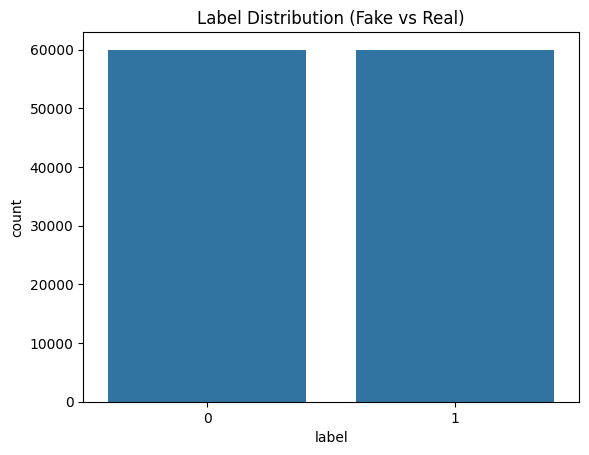

In [9]:
#Label Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=train_df)
plt.title("Label Distribution (Fake vs Real)")
plt.show()

In [10]:
#Check Missing Values
print(train_df.isnull().sum())

statement    0
label        0
dtype: int64


In [11]:
#Show 5 Sample Entries
train_df.sample(5)

,statement,label
3072,Google Slashes IPO Price UPDATED: Search engin...,1
89145,Bush hails Blair as #39;visionary leader #39;...,1
70029,"Kite increases lead in Sonoma SONOMA, Californ...",0
53663,Election doubt as UN staff ask to pull out Fre...,1
112581,16 Killed in Venezuelan Plane Crash A Venezuel...,1


DAY 3

# 📅 Day 3: Tokenization

- Used BERT tokenizer (bert-base-uncased)
- Converted text into input_ids and attention_mask
- Applied padding and truncation (max_length=128)
- Created PyTorch Dataset class

In [12]:

#Load Tokenizer
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [13]:
#Try on ONE example
sample_text = train_df['statement'].iloc[0]

tokens = tokenizer(
    sample_text,
    padding='max_length',
    truncation=True,
    max_length=128
)

print(tokens)

{'input_ids': [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [14]:
#Check Length
print(len(tokens['input_ids']))

128


In [15]:
#Create Dataset Class (PyTorch)
import torch

class FakeNewsDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts.iloc[idx],
            padding='max_length',
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        item = {key: val.squeeze() for key, val in encoding.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])

        return item

In [16]:
#Create Train Dataset
train_dataset = FakeNewsDataset(
    train_df['statement'],
    train_df['label']
)

In [17]:
#Test
sample = train_dataset[0]

print(sample)

{'input_ids': tensor([  101,  2813,  2358,  1012,  6468, 15020,  2067,  2046,  1996,  2304,
         1006, 26665,  1007, 26665,  1011,  2460,  1011, 19041,  1010,  2813,
         2395,  1005,  1055,  1040, 11101,  2989,  1032,  2316,  1997, 11087,
         1011, 22330,  8713,  2015,  1010,  2024,  3773,  2665,  2153,  1012,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0, 

DAY 4–5

In [18]:
#Load the Model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
#Create Validation Split
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['statement'],
    train_df['label'],
    test_size=0.2
)

In [20]:
#Create Datasets
train_dataset = FakeNewsDataset(train_texts, train_labels)
val_dataset = FakeNewsDataset(val_texts, val_labels)

In [21]:
!pip install -U transformers

In [22]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir="./logs"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [23]:
#Load Model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['statement'],
    train_df['label'],
    test_size=0.2
)

In [25]:
train_dataset = FakeNewsDataset(train_texts, train_labels)
val_dataset = FakeNewsDataset(val_texts, val_labels)

In [26]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [27]:
trainer.train()

Step,Training Loss
500,0.320116
1000,0.252942
1500,0.239312
2000,0.230177
2500,0.225722
3000,0.203992
3500,0.214607
4000,0.212962
4500,0.202619
5000,0.216482


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=24000, training_loss=0.16422305997212727, metrics={'train_runtime': 5925.392, 'train_samples_per_second': 32.403, 'train_steps_per_second': 4.05, 'total_flos': 1.262933065728e+16, 'train_loss': 0.16422305997212727, 'epoch': 2.0})

In [28]:
predictions = trainer.predict(val_dataset)

In [29]:
import numpy as np

y_pred = np.argmax(predictions.predictions, axis=1)

In [30]:
from sklearn.metrics import classification_report

print(classification_report(val_labels, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96     11855
           1       0.97      0.95      0.96     12145

    accuracy                           0.96     24000
   macro avg       0.96      0.96      0.96     24000
weighted avg       0.96      0.96      0.96     24000



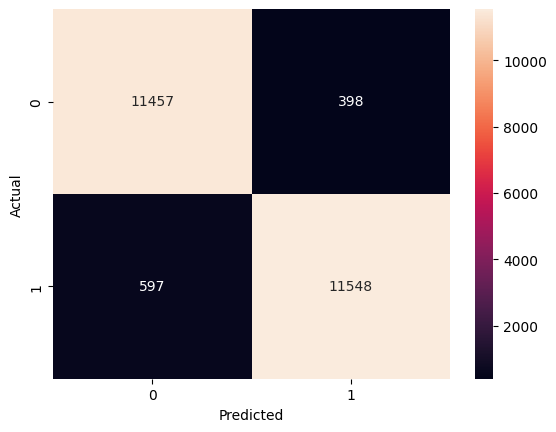

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
val_texts = list(val_texts)
val_labels = list(val_labels)

In [34]:
wrong_indices = []

for i in range(len(y_pred)):
    if y_pred[i] != val_labels[i]:
        wrong_indices.append(i)

print("Total wrong predictions:", len(wrong_indices))

Total wrong predictions: 995


In [35]:
for i in wrong_indices[:5]:
    print("TEXT:", val_texts[i])
    print("Actual:", val_labels[i])
    print("Predicted:", y_pred[i])
    print("-"*50)

TEXT: Wall Street Set to Open Down (Reuters) Reuters - U.S. shares were expected to open lower\on Wednesday after crude oil pushed to a fresh high overnight,\while Web search engine Google Inc. dented sentiment as it\slashed the price range on its initial public offering.\In a statement posted on its IPO Web site, Google said it had\cut the range on its IPO to  #36;85- #36;95 per share from  #36;108- #36;135\previously, a 26 percent reduction at the mid-point of the\range.
Actual: 1
Predicted: 0
--------------------------------------------------
TEXT: GB badminton duo make final Nathan Robertson and Gail Emms reach the final of the badminton mixed doubles.
Actual: 0
Predicted: 1
--------------------------------------------------
TEXT: Google CEO Says Company Proud of Auction-Style IPO  SAN FRANCISCO (Reuters) - The chief executive of Google  Inc. said the Web search company was "proud" of its recent  auction-style initial public offering, but said he did not know  if it would change th

Error Analysis:

1. Several misclassified samples were short headlines with limited contextual information, making it difficult for the model to infer the correct label.
2. Some inputs contained ambiguous or neutral language, which blurred the distinction between fake and real news.
3. Certain samples had mixed signals, combining factual statements with opinion-like tone, leading to confusion in classification.
4. Domain-specific content such as sports or niche topics was sometimes misclassified due to limited representation in training data.
5. Noisy or improperly formatted text (e.g., HTML entities like "AT&T") negatively impacted model understanding and prediction accuracy.

These observations indicate that while the model performs well overall, it struggles in cases with limited context, ambiguity, and noisy inputs.


In [36]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [38]:
train_texts = [str(text) for text in train_texts]
val_texts = [str(text) for text in val_texts]

In [39]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

In [40]:
train_texts = [str(text) if text is not None else "" for text in train_texts]
val_texts = [str(text) if text is not None else "" for text in val_texts]

In [41]:
train_dataset = FakeNewsDataset(train_encodings, train_labels)
val_dataset = FakeNewsDataset(val_encodings, val_labels)

In [42]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [43]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    save_strategy="no",
    logging_steps=500
)

In [44]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [46]:
import torch

class FakeNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)   # ensure list

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])  # ✅ fixed
        return item

    def __len__(self):
        return len(self.labels)

In [47]:
train_dataset = FakeNewsDataset(train_encodings, train_labels)
val_dataset = FakeNewsDataset(val_encodings, val_labels)

In [48]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [49]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    save_strategy="no",
    logging_steps=500
)

In [50]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [52]:
trainer.train()

Step,Training Loss


KeyboardInterrupt: 

In [53]:
predictions = trainer.predict(val_dataset)

import numpy as np
y_pred_new = np.argmax(predictions.predictions, axis=1)

Step,Training Loss


In [54]:
from sklearn.metrics import accuracy_score

print("DistilBERT Accuracy:", accuracy_score(val_labels, y_pred_new))

DistilBERT Accuracy: 0.945625


In [55]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 65.6 MB/s eta 0:00:00


In [56]:
trainer.save_model("fake_news_model")
tokenizer.save_pretrained("fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_model/tokenizer_config.json', 'fake_news_model/tokenizer.json')

In [57]:
import streamlit as st
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load model and tokenizer
model = DistilBertForSequenceClassification.from_pretrained("fake_news_model")
tokenizer = DistilBertTokenizer.from_pretrained("fake_news_model")

model.eval()

# UI
st.title("📰 Fake News Detection App")

text = st.text_area("Enter news text:")

if st.button("Predict"):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    prediction = torch.argmax(logits).item()

    if prediction == 1:
        st.success("✅ Real News")
    else:
        st.error("❌ Fake News")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

2026-03-18 16:50:32.579 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 16:50:32.688 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-18 16:50:32.689 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 16:50:32.693 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 16:50:32.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 16:50:32.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 16:50:32.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-18 16:50:32.701 Thread 'MainThread': mi

In [59]:
%%writefile app.py

import streamlit as st
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained("fake_news_model")
tokenizer = DistilBertTokenizer.from_pretrained("fake_news_model")

model.eval()

st.title("📰 Fake News Detection App")

text = st.text_area("Enter news text:")

if st.button("Predict"):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    prediction = torch.argmax(outputs.logits).item()

    if prediction == 1:
        st.success("✅ Real News")
    else:
        st.error("❌ Fake News")

Writing app.py


In [60]:
!ls

app.py	fake_news_model  results  sample_data


In [61]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦

⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://short-brooms-wash.loca.lt
/root/.npm/_npx/75ac80b86e83d4a2/node_modules/localtunnel/bin/lt.js:81
    throw err;
    ^

Error: connection refused: localtunnel.me:20975 (check your firewall settings)
    at Socket.<anonymous> (/root/.npm/_npx/75ac80b86e83d4a2/node_modules/localtunnel/lib/TunnelCluster.js:52:11)
    at Socket.emit (node:events:524:28)
    at emitErrorNT (node:internal/streams/destroy:169:8)
    at emitErrorCloseNT (node:internal/streams/destroy:128:3)
    at process.processTicksAndRejections (node:internal/process/task_queues:82:21)

Node.js v20.19.0
⠙
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.14.238:8501

  Stopping...


In [62]:
!pip install pyngrok

In [65]:
!pip install gradio

In [66]:
import gradio as gr
import torch

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits).item()

    return "✅ Real News" if pred == 1 else "❌ Fake News"

gr.Interface(fn=predict, inputs="text", outputs="text").launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c6c03830efa7e398b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
